<div style="text-align: center; font-size: 30px;">
  <strong>Dating App Dataset</strong>
</div>


# Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = "Dating App Dataset.csv"
df= pd.read_csv(file_path)

# Displaying the first five rows of dataset

In [3]:
df.head()

,User ID,Age,Gender,Height,Interests,Looking For,Children,Education Level,Occupation,Swiping History,Frequency of Usage
0,1,30,Male,5.240385,"['Sports', 'Cooking', 'Hiking', 'Music', 'Movi...",Casual Dating,No,High School,Student,96,Weekly
1,2,27,Female,4.937625,"['Sports', 'Reading']",Friendship,Yes,Master's Degree,Artist,96,Monthly
2,3,29,Female,5.806296,['Sports'],Casual Dating,No,Bachelor's Degree,Social Media Influencer,64,Daily
3,4,29,Female,5.101402,['Reading'],Marriage,No,Ph.D.,Doctor,67,Daily
4,5,32,Male,5.986670,"['Sports', 'Hiking', 'Music', 'Movies', 'Readi...",Long-term Relationship,Yes,Ph.D.,Engineer,93,Monthly


# Quick walk through dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User ID             500 non-null    int64  
 1   Age                 500 non-null    int64  
 2   Gender              500 non-null    object 
 3   Height              500 non-null    float64
 4   Interests           500 non-null    object 
 5   Looking For         500 non-null    object 
 6   Children            500 non-null    object 
 7   Education Level     500 non-null    object 
 8   Occupation          500 non-null    object 
 9   Swiping History     500 non-null    int64  
 10  Frequency of Usage  500 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 43.1+ KB


The dataset has 11 columns with different data types. User ID, Age, and Swiping History are integers. Height is a floating-point number. Gender, Interests, Looking For, Children, Education Level, Occupation, and Frequency of Usage are categorical data. The dataset includes both numerical and categorical information.

In [5]:
df.isnull().sum()

User ID               0
Age                   0
Gender                0
Height                0
Interests             0
Looking For           0
Children              0
Education Level       0
Occupation            0
Swiping History       0
Frequency of Usage    0
dtype: int64

There are no missing data in this dataset

<h2>1. Description of the whole dataset</h2>

In [6]:
df.describe()

,User ID,Age,Height,Swiping History
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,26.984000,5.466491,50.620000
std,144.481833,5.123304,0.377757,29.637415
min,1.000000,18.000000,4.807386,0.000000
25%,125.750000,23.000000,5.131676,25.000000
50%,250.500000,27.000000,5.458365,50.000000
75%,375.250000,32.000000,5.805893,78.000000
max,500.000000,35.000000,6.091946,100.000000


The dataset consists of 500 records, each identified by a unique User ID ranging from 1 to 500. The Age of users varies between 18 and 35 years, with an average of 26.98 years. The Height is measured within a range of 4.80 to 6.09 units, with a mean value of 5.46. Additionally, the Swiping History, which likely represents user engagement, ranges from 0 to 100 swipes, with an average of 50.62 swipes.

<h1>2. Age</h1> 

###  2.1 Age Statistical Value

In [7]:
age_mean = df['Age'].mean()
age_median= df["Age"].median()
age_std = df['Age'].std()
age_min= df["Age"].min()
age_max= df["Age"].max()
age_mode=df['Age'].mode()
age_range= age_max - age_min

print(f"Mean: {age_mean}")
print(f"Median: {age_median}")
print(f"Standard Deviation: {age_std}")
print(f"Range: {age_range} (Min: {age_min}, Max: {age_max})")
print(f"Mode: {age_mode}")

Mean: 26.984
Median: 27.0
Standard Deviation: 5.123303668626521
Range: 17 (Min: 18, Max: 35)
Mode: 0    32
1    33
Name: Age, dtype: int64


### 2.2 Age Distribution

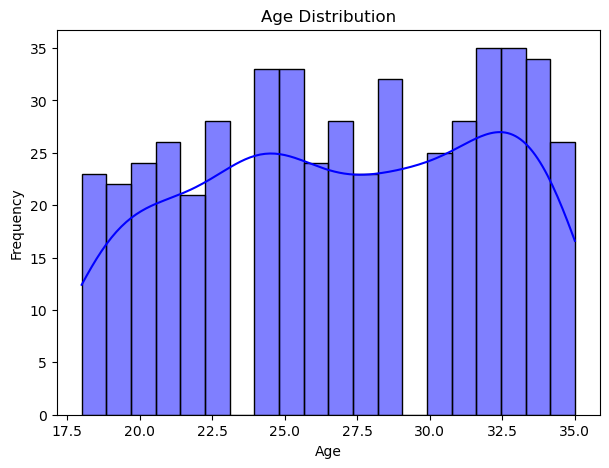

In [8]:
plt.figure(figsize=(7,5))
sns.histplot(df["Age"], bins=20, kde= True, color= "Blue")
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 2.3 Distributuon By Age Group and Gender

In [9]:
filtered_data = df[(df['Age'] >= 18) & (df['Age'] <= 35)]

#custom age bins (18-22, 23-26, 27-31, 31-35)
age_bins = [18, 22, 26, 31, 35]
age_labels = ['18-22', '23-26', '27-31', '31-35']
filtered_data['Age Group'] = pd.cut(filtered_data['Age'], bins=age_bins, labels=age_labels, right=True)
age_group_gender = pd.crosstab(filtered_data['Age Group'], filtered_data['Gender'])
print(age_group_gender)

Gender     Female  Male
Age Group              
18-22          49    44
23-26          61    57
27-31          67    69
31-35          60    70


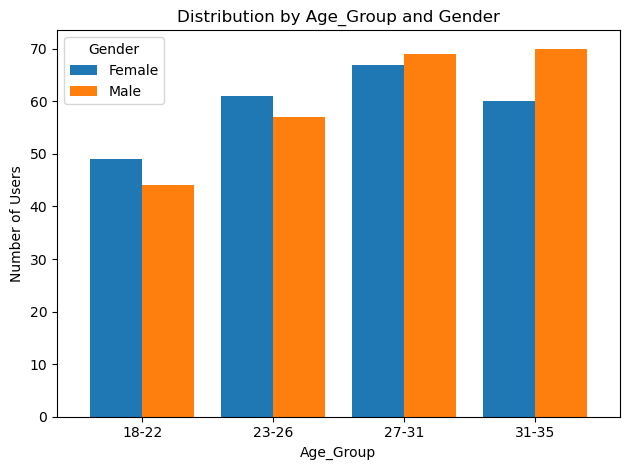

In [10]:
age_group_gender.plot(kind='bar', width=0.8)
plt.title("Distribution by Age_Group and Gender")
plt.xlabel("Age_Group")
plt.ylabel("Number of Users")
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<h1>3. Gender</h1> 

   ### 3.1 Gender Distribution

In [11]:
gender_counts = df['Gender'].value_counts()
gender_proportions = df['Gender'].value_counts(normalize=True) * 100

print("Gender Distribution:")
print(gender_counts)
print("\nGender Proportions (%):")
print(gender_proportions)

Gender Distribution:
Gender
Male      251
Female    249
Name: count, dtype: int64

Gender Proportions (%):
Gender
Male      50.2
Female    49.8
Name: proportion, dtype: float64


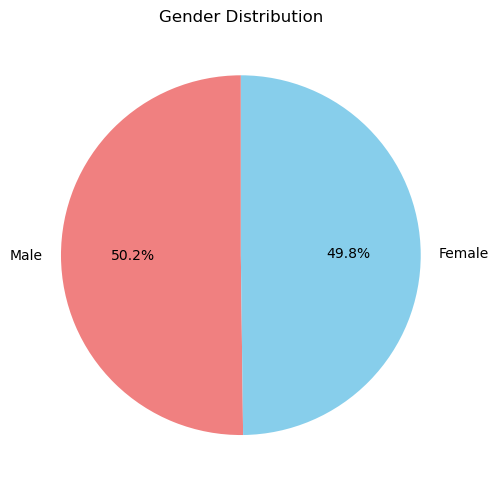

In [12]:
plt.figure(figsize=(7, 5))
custom_colors = ['lightcoral', 'skyblue']
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=custom_colors)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

<h1>4. Education Level</h1> 

In [13]:
edu_counts = df['Education Level'].value_counts()
edu_proportions = df['Education Level'].value_counts(normalize=True) * 100

print("Education Level Distribution:")
print(edu_counts)
print("\nEducation Level Proportions (%):")
print(edu_proportions)

Education Level Distribution:
Education Level
Bachelor's Degree    143
High School          122
Master's Degree      122
Ph.D.                113
Name: count, dtype: int64

Education Level Proportions (%):
Education Level
Bachelor's Degree    28.6
High School          24.4
Master's Degree      24.4
Ph.D.                22.6
Name: proportion, dtype: float64


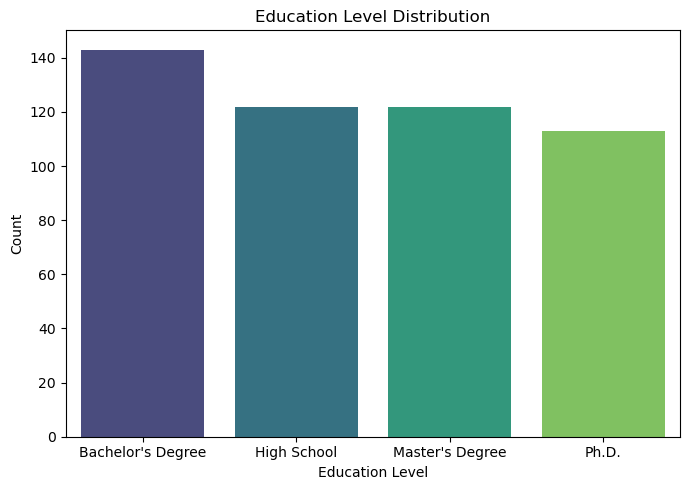

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(x=edu_counts.index, y=edu_counts.values, palette='viridis')
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


<h1>4. Looking For</h1>

In [15]:
looking_for_counts = df['Looking For'].value_counts()
looking_for_proportions = df['Looking For'].value_counts(normalize=True) * 100

print("Looking For:")
print(looking_for_counts)
print("\nLooking For Proportions (%):")
print(looking_for_proportions)

Looking For:
Looking For
Casual Dating             137
Long-term Relationship    137
Friendship                114
Marriage                  112
Name: count, dtype: int64

Looking For Proportions (%):
Looking For
Casual Dating             27.4
Long-term Relationship    27.4
Friendship                22.8
Marriage                  22.4
Name: proportion, dtype: float64


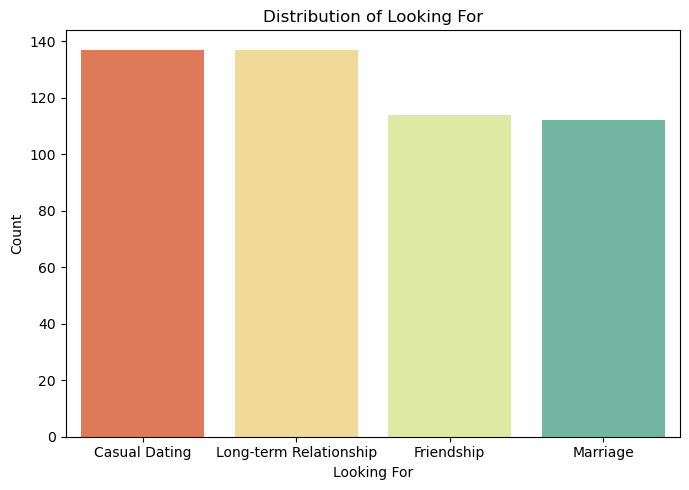

In [16]:
plt.figure(figsize=(7, 5))
sns.barplot(x=looking_for_counts.index, y=looking_for_counts.values, palette='Spectral')
plt.title("Distribution of Looking For")
plt.xlabel("Looking For")
plt.ylabel("Count")
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


<h1>5. Childern</h1>

In [17]:
children_counts = df['Children'].value_counts()
children_proportions = df['Children'].value_counts(normalize=True) * 100

print("Children Distribution:")
print(children_counts)
print("\nChildren Proportions (%):")
print(children_proportions)

Children Distribution:
Children
No       172
Yes      170
Maybe    158
Name: count, dtype: int64

Children Proportions (%):
Children
No       34.4
Yes      34.0
Maybe    31.6
Name: proportion, dtype: float64


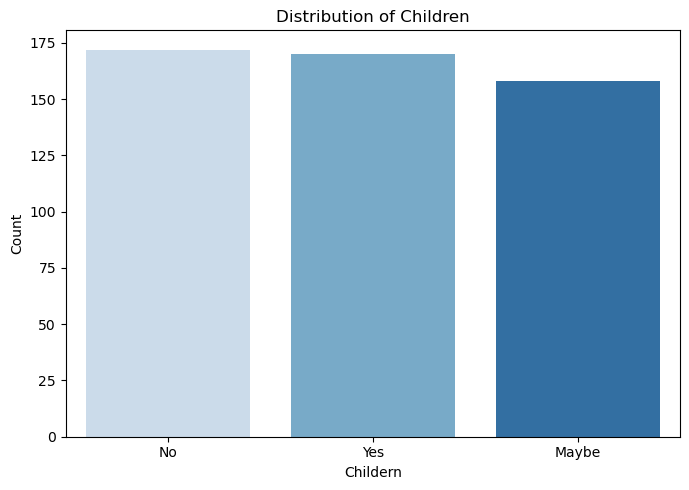

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(x=children_counts.index, y=children_counts.values, palette='Blues')
plt.title("Distribution of Children")
plt.xlabel("Childern")
plt.ylabel("Count")
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


<h1>6. Occupation</h1>

In [19]:
occupation_counts = df['Occupation'].value_counts()
occupation_proportions = df['Occupation'].value_counts(normalize=True) * 100

print("Occupation Distribution:")
print(occupation_counts)
print("\nOccupation Proportions (%):")
print(occupation_proportions)

Occupation Distribution:
Occupation
Artist                     69
Entrepreneur               67
Business Owner             66
Social Media Influencer    63
Engineer                   63
Doctor                     61
Student                    57
Teacher                    54
Name: count, dtype: int64

Occupation Proportions (%):
Occupation
Artist                     13.8
Entrepreneur               13.4
Business Owner             13.2
Social Media Influencer    12.6
Engineer                   12.6
Doctor                     12.2
Student                    11.4
Teacher                    10.8
Name: proportion, dtype: float64


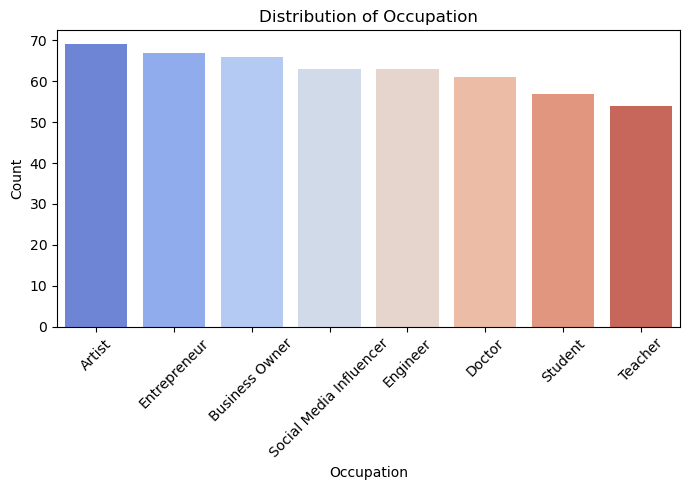

In [20]:
plt.figure(figsize=(7, 5))
sns.barplot(x=occupation_counts.index, y=occupation_counts.values, palette='coolwarm')
plt.title("Distribution of Occupation")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


<h1>7. Usage</h1> 

In [21]:
usage_counts = df['Frequency of Usage'].value_counts()
usage_proportions = df['Frequency of Usage'].value_counts(normalize=True) * 100

print("Distribution as per the usage")
print(usage_counts)
print("\nUsage Proportions (%):")
print(usage_proportions)

Distribution as per the usage
Frequency of Usage
Daily      182
Weekly     168
Monthly    150
Name: count, dtype: int64

Usage Proportions (%):
Frequency of Usage
Daily      36.4
Weekly     33.6
Monthly    30.0
Name: proportion, dtype: float64


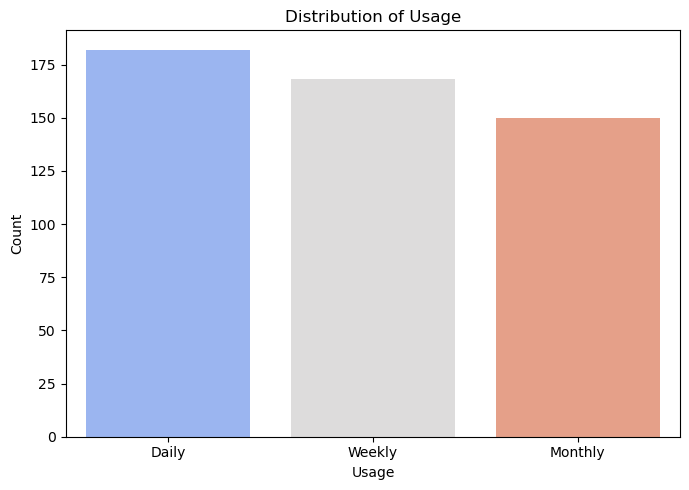

In [22]:
plt.figure(figsize=(7, 5))
sns.barplot(x=usage_counts.index, y=usage_counts.values, palette='coolwarm')
plt.title("Distribution of Usage")
plt.xlabel("Usage")
plt.ylabel("Count")
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


# Preprocessing 

In [23]:
# Drop the User ID as it has no significance
df.drop(columns=['User ID'], inplace=True)

In [24]:
df.head()

,Age,Gender,Height,Interests,Looking For,Children,Education Level,Occupation,Swiping History,Frequency of Usage
0,30,Male,5.240385,"['Sports', 'Cooking', 'Hiking', 'Music', 'Movi...",Casual Dating,No,High School,Student,96,Weekly
1,27,Female,4.937625,"['Sports', 'Reading']",Friendship,Yes,Master's Degree,Artist,96,Monthly
2,29,Female,5.806296,['Sports'],Casual Dating,No,Bachelor's Degree,Social Media Influencer,64,Daily
3,29,Female,5.101402,['Reading'],Marriage,No,Ph.D.,Doctor,67,Daily
4,32,Male,5.986670,"['Sports', 'Hiking', 'Music', 'Movies', 'Readi...",Long-term Relationship,Yes,Ph.D.,Engineer,93,Monthly


<b>There are some ordinal features and nominal features in this dataset. We will first make separate list of ordinal and nominal features. Then apply correct transformation for both type of features.</b>

In [25]:
Nominal_feat = ['Gender', 'Occupation', 'Children', 'Looking For']

In [26]:
Ordinal_feat = ['Education Level', 'Frequency of Usage']

<b>We are going to count the number of interests for each row and replace each row with the number of interests.</b>

In [27]:
df['Interests'] = df['Interests'].str.count(',')+1

In [29]:
df.head()

,Age,Gender,Height,Interests,Looking For,Children,Education Level,Occupation,Swiping History,Frequency of Usage
0,30,Male,5.240385,7,Casual Dating,No,High School,Student,96,Weekly
1,27,Female,4.937625,2,Friendship,Yes,Master's Degree,Artist,96,Monthly
2,29,Female,5.806296,1,Casual Dating,No,Bachelor's Degree,Social Media Influencer,64,Daily
3,29,Female,5.101402,1,Marriage,No,Ph.D.,Doctor,67,Daily
4,32,Male,5.986670,5,Long-term Relationship,Yes,Ph.D.,Engineer,93,Monthly


<b>Now handling the ordinal features.</b>

In [30]:
from sklearn.preprocessing import OrdinalEncoder

In [32]:
oe_education = OrdinalEncoder(categories=[["High School", "Bachelor's Degree", "Master's Degree", "Ph.D."]])

In [33]:
df['Education Level'] = oe_education.fit_transform(df[['Education Level']])

In [34]:
df.head()

,Age,Gender,Height,Interests,Looking For,Children,Education Level,Occupation,Swiping History,Frequency of Usage
0,30,Male,5.240385,7,Casual Dating,No,0.0,Student,96,Weekly
1,27,Female,4.937625,2,Friendship,Yes,2.0,Artist,96,Monthly
2,29,Female,5.806296,1,Casual Dating,No,1.0,Social Media Influencer,64,Daily
3,29,Female,5.101402,1,Marriage,No,3.0,Doctor,67,Daily
4,32,Male,5.986670,5,Long-term Relationship,Yes,3.0,Engineer,93,Monthly


In [35]:
oe_frequency = OrdinalEncoder(categories=[["Monthly", "Weekly", "Daily"]])

In [36]:
df['Frequency of Usage'] = oe_frequency.fit_transform(df[['Frequency of Usage']])

In [37]:
df.head()

,Age,Gender,Height,Interests,Looking For,Children,Education Level,Occupation,Swiping History,Frequency of Usage
0,30,Male,5.240385,7,Casual Dating,No,0.0,Student,96,1.0
1,27,Female,4.937625,2,Friendship,Yes,2.0,Artist,96,0.0
2,29,Female,5.806296,1,Casual Dating,No,1.0,Social Media Influencer,64,2.0
3,29,Female,5.101402,1,Marriage,No,3.0,Doctor,67,2.0
4,32,Male,5.986670,5,Long-term Relationship,Yes,3.0,Engineer,93,0.0


In [40]:
df_modified = pd.get_dummies(df, columns=Nominal_feat, drop_first=True, dtype=float)

In [41]:
df_modified.head()

,Age,Height,Interests,Education Level,Swiping History,Frequency of Usage,Gender_Male,Occupation_Business Owner,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Social Media Influencer,Occupation_Student,Occupation_Teacher,Children_No,Children_Yes,Looking For_Friendship,Looking For_Long-term Relationship,Looking For_Marriage
0,30,5.240385,7,0.0,96,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,27,4.937625,2,2.0,96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,29,5.806296,1,1.0,64,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,29,5.101402,1,3.0,67,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,32,5.986670,5,3.0,93,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [44]:
#To remove the dummy variable trap.
df_modified.drop(columns = ['Children_No'], inplace=True)

In [45]:
df_modified.head()

,Age,Height,Interests,Education Level,Swiping History,Frequency of Usage,Gender_Male,Occupation_Business Owner,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Social Media Influencer,Occupation_Student,Occupation_Teacher,Children_Yes,Looking For_Friendship,Looking For_Long-term Relationship,Looking For_Marriage
0,30,5.240385,7,0.0,96,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,27,4.937625,2,2.0,96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,29,5.806296,1,1.0,64,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,29,5.101402,1,3.0,67,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,32,5.986670,5,3.0,93,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# K-Means Clustering Algorithm

## Elbow method to estimate the number of clusters in this dataset.

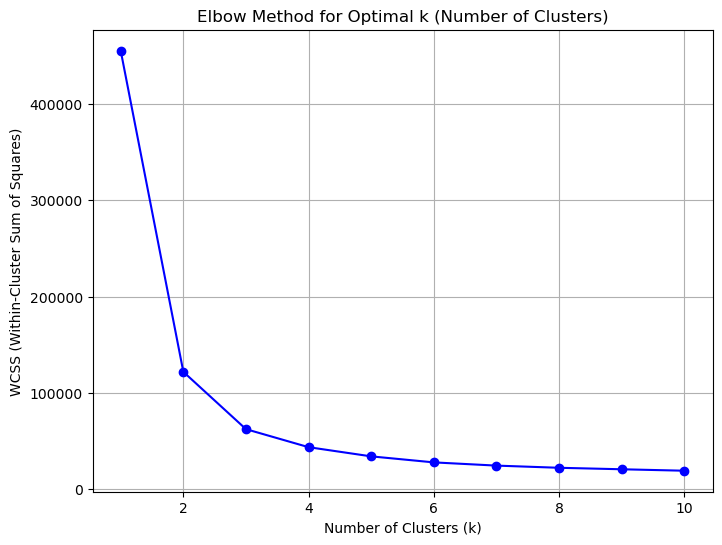

In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Define the range of k values (number of clusters)
k_range = range(1, 11)
wcss = []

# Step 2: Perform K-Means clustering for each value of k and compute WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_modified)  # Use the preprocessed dataset
    wcss.append(kmeans.inertia_)  # WCSS is the inertia attribute

# Step 3: Plot the Elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k (Number of Clusters)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

<b>From this elbow method number of clusters would be 3.</b>

# K-means clustering

In [47]:
model = KMeans(n_clusters = 3, init = "k-means++", random_state = 0)
model_kmeans = model.fit_predict(df_modified)

In [49]:
print("First five predicted cluster class: ",model_kmeans[:6])

First five predicted cluster class:  [1 1 2 2 1 2]


# Assigning the clusters 

In [50]:
df_modified['Cluster'] = model_kmeans

In [51]:
df_modified.head()

,Age,Height,Interests,Education Level,Swiping History,Frequency of Usage,Gender_Male,Occupation_Business Owner,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Social Media Influencer,Occupation_Student,Occupation_Teacher,Children_Yes,Looking For_Friendship,Looking For_Long-term Relationship,Looking For_Marriage,Cluster
0,30,5.240385,7,0.0,96,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,27,4.937625,2,2.0,96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
2,29,5.806296,1,1.0,64,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,29,5.101402,1,3.0,67,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
4,32,5.986670,5,3.0,93,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1


# Visualization of clusters

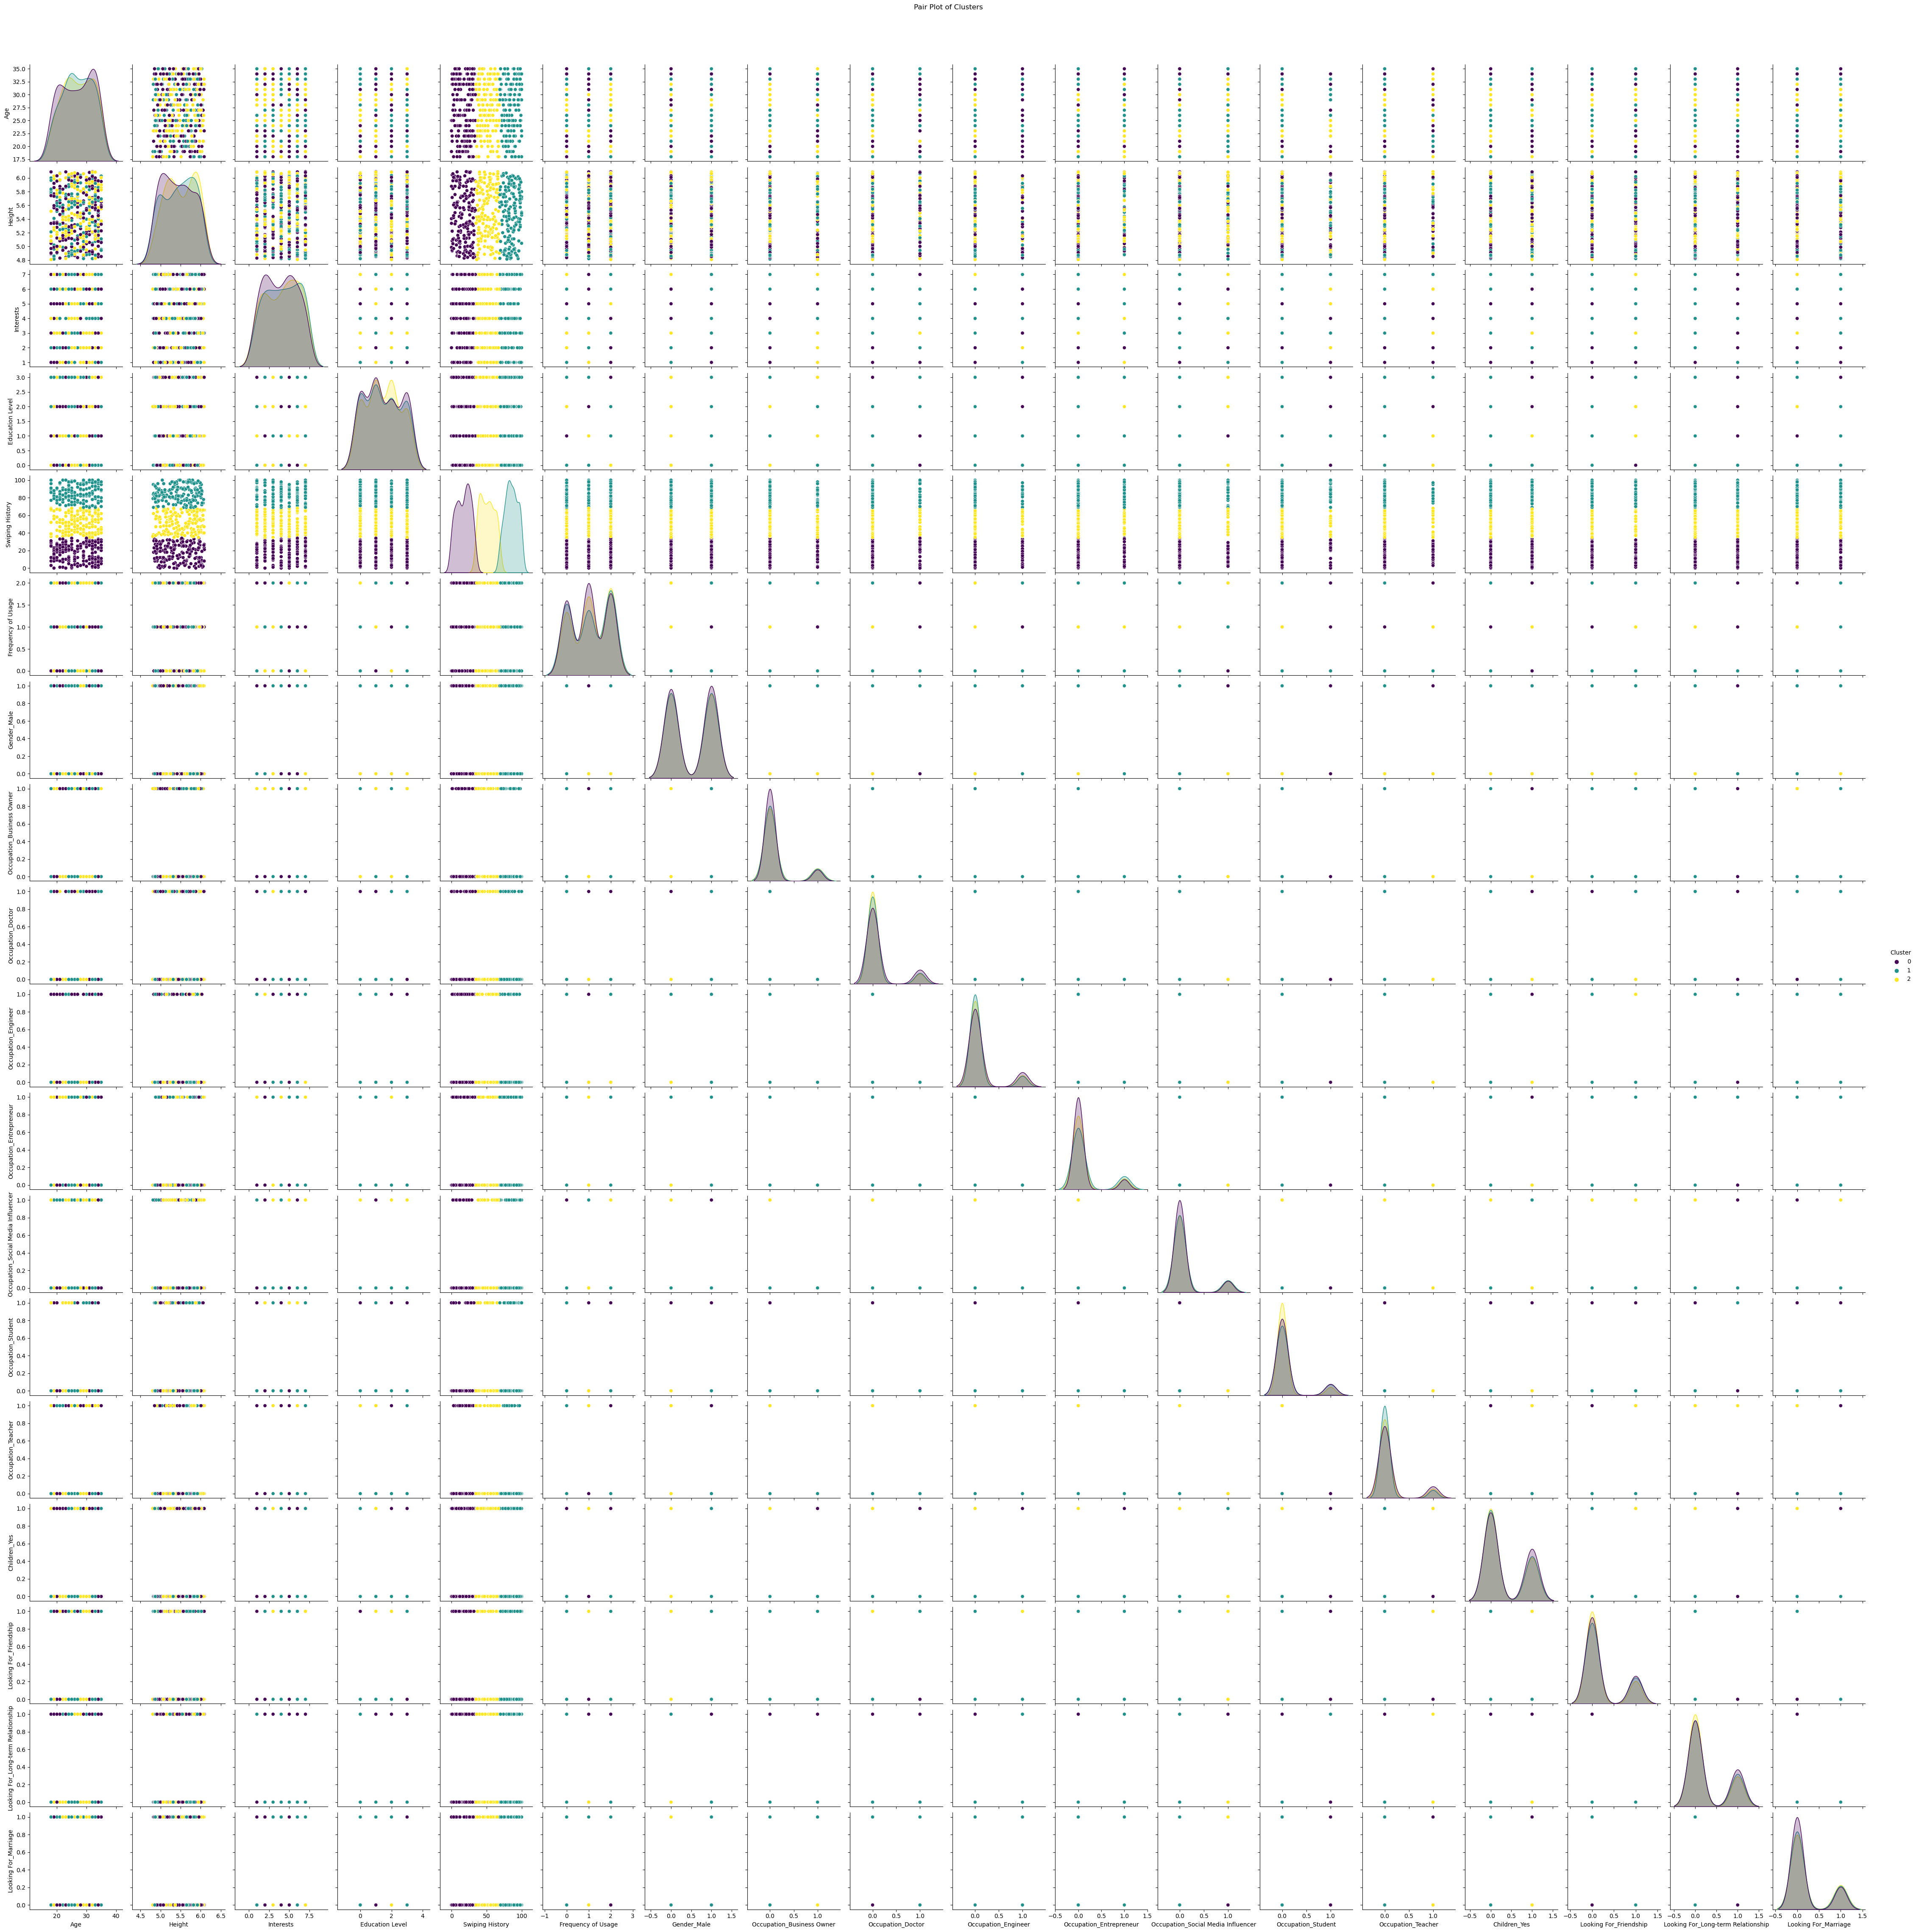

In [52]:
sns.pairplot(df_modified, hue="Cluster", diag_kind="kde", palette="viridis")
plt.suptitle('Pair Plot of Clusters', y=1.02)
plt.show()

<Axes: xlabel='Swiping History', ylabel='Age'>

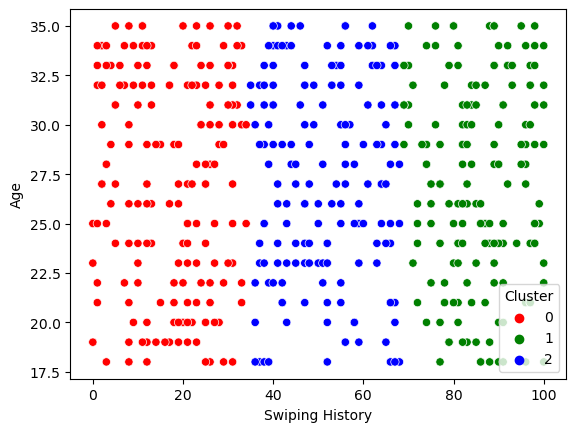

In [54]:
sns.scatterplot(x = df_modified['Swiping History'], y = df_modified['Age'], hue = df_modified['Cluster'], palette=['r','g','b'])

<Axes: xlabel='Swiping History', ylabel='Height'>

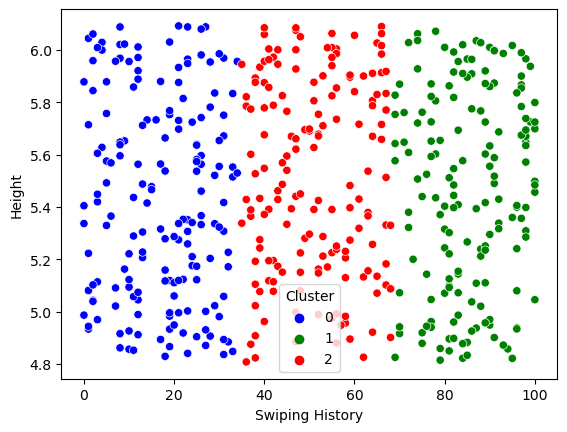

In [55]:
sns.scatterplot(x = df_modified['Swiping History'], y = df_modified['Height'], hue = df_modified['Cluster'], palette=['b','g','r'])

<Axes: xlabel='Swiping History', ylabel='Age'>

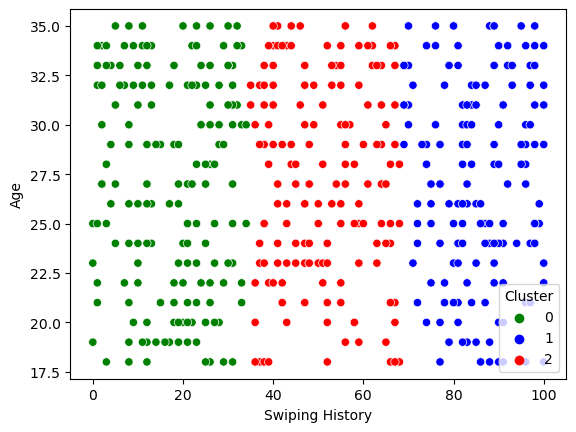

In [60]:
sns.scatterplot(x=df_modified['Swiping History'], y=df_modified['Age'], hue=df_modified['Cluster'], palette=['g','b','r'])